# Biomedical Data Analysis – Heart Failure Clinical Records

## Project Overview

This project analyzes the clinical characteristics of patients with heart failure using a publicly available biomedical dataset.

The main goal is to explore whether selected clinical variables are associated with mortality and to investigate whether machine learning models can predict the occurrence of death using patient-level clinical data.

The project combines exploratory data analysis, statistical hypothesis testing, and machine learning methods.

### Research Questions

1. Which clinical variables differ between patients who experienced death and those who did not?
2. Are these observed differences statistically significant?
3. Can machine learning models predict mortality based on the available clinical features?
4. Which variables contribute most to the predictions of the machine learning models?

### Methods

The analysis consists of three main stages:

* **Exploratory Data Analysis (EDA):** Examining the distribution of clinical variables and comparing patients according to mortality outcome.
* **Statistical Analysis:** Using independent t-tests for continuous variables and chi-square tests for categorical variables.
* **Machine Learning:** Training Logistic Regression and Random Forest models to predict the `DEATH_EVENT` outcome.

The analysis focuses on identifying associations and predictive patterns rather than establishing causal relationships.


In [6]:
import pandas as pd

 1. Data Loading and Inspection


In [7]:
df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")

In [11]:
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [12]:
df.shape

(299, 13)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [14]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [15]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


2. Exploratory Data Analysis

In [16]:
import matplotlib.pyplot as plt

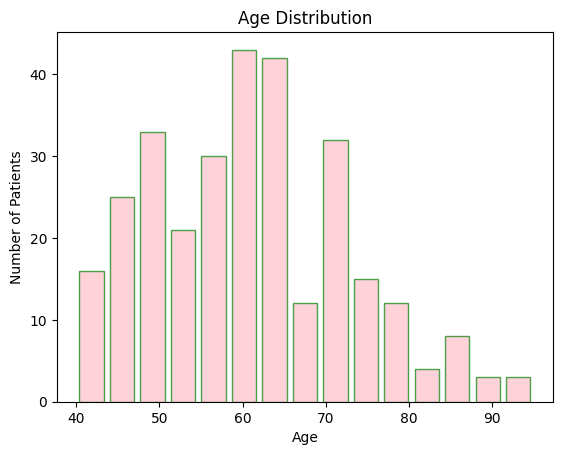

In [18]:
plt.hist(df["age"], bins=15, rwidth=0.8, color='pink', edgecolor='green', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()

In [19]:
df.groupby("DEATH_EVENT")["age"].mean()

DEATH_EVENT
0    58.761906
1    65.215281
Name: age, dtype: float64

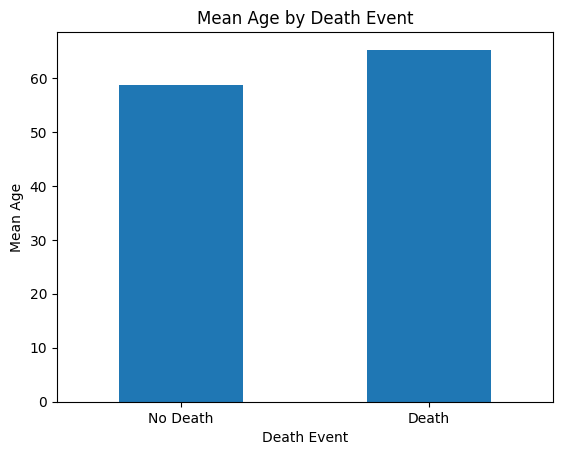

In [20]:
df.groupby("DEATH_EVENT")["age"].mean().plot(kind="bar")

plt.xlabel("Death Event")
plt.ylabel("Mean Age")
plt.title("Mean Age by Death Event")
plt.xticks([0, 1], ["No Death", "Death"], rotation=0)

plt.show()

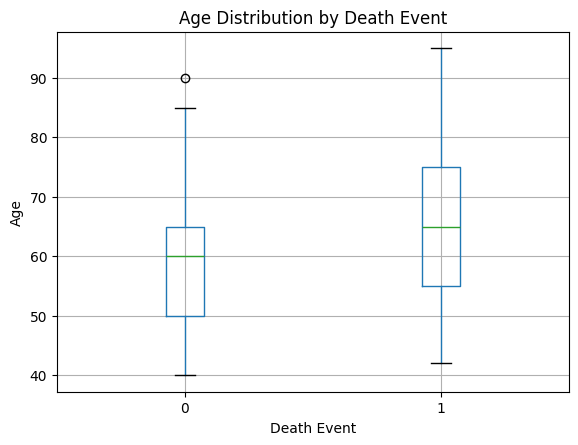

In [21]:
df.boxplot(column="age", by="DEATH_EVENT")

plt.xlabel("Death Event")
plt.ylabel("Age")
plt.title("Age Distribution by Death Event")
plt.suptitle("")

plt.show()

In [22]:
df.groupby("DEATH_EVENT")["ejection_fraction"].mean()

DEATH_EVENT
0    40.26601
1    33.46875
Name: ejection_fraction, dtype: float64

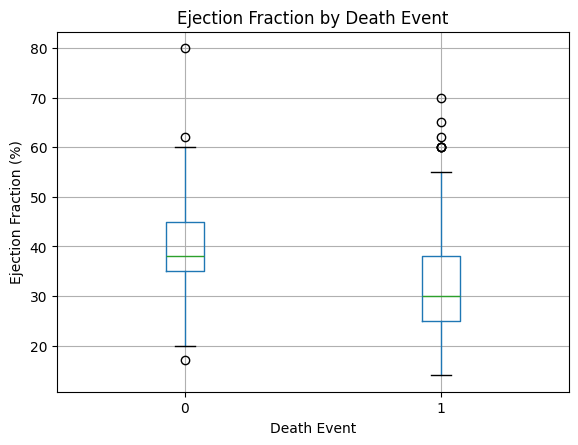

In [23]:
df.boxplot(column="ejection_fraction", by="DEATH_EVENT")

plt.xlabel("Death Event")
plt.ylabel("Ejection Fraction (%)")
plt.title("Ejection Fraction by Death Event")
plt.suptitle("")

plt.show()

In [24]:
from scipy.stats import ttest_ind

In [25]:
age_no_death = df[df["DEATH_EVENT"] == 0]["age"]
age_death = df[df["DEATH_EVENT"] == 1]["age"]

ttest_ind(age_no_death, age_death)

TtestResult(statistic=np.float64(-4.520613504937705), pvalue=np.float64(8.916762946533357e-06), df=np.float64(297.0))

In [26]:
ef_no_death = df[df["DEATH_EVENT"] == 0]["ejection_fraction"]
ef_death = df[df["DEATH_EVENT"] == 1]["ejection_fraction"]

ttest_ind(ef_no_death, ef_death)

TtestResult(statistic=np.float64(4.80562826839639), pvalue=np.float64(2.452897418208845e-06), df=np.float64(297.0))

In [27]:
df.groupby("DEATH_EVENT").agg({
    "age": "mean",
    "ejection_fraction": "mean",
    "serum_creatinine": "mean",
    "serum_sodium": "mean",
    "platelets": "mean"
})

,age,ejection_fraction,serum_creatinine,serum_sodium,platelets
DEATH_EVENT,,,,,
0,58.761906,40.26601,1.184877,137.216749,266657.489901
1,65.215281,33.46875,1.835833,135.375000,256381.044792


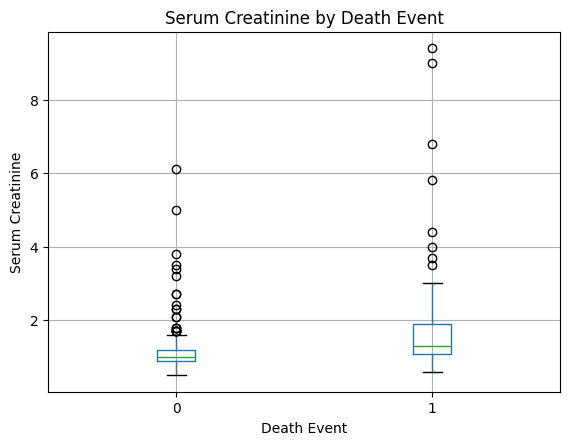

In [28]:
df.boxplot(column="serum_creatinine", by="DEATH_EVENT")

plt.xlabel("Death Event")
plt.ylabel("Serum Creatinine")
plt.title("Serum Creatinine by Death Event")
plt.suptitle("")

plt.show()

In [29]:
creatinine_no_death = df[df["DEATH_EVENT"] == 0]["serum_creatinine"]
creatinine_death = df[df["DEATH_EVENT"] == 1]["serum_creatinine"]

ttest_ind(creatinine_no_death, creatinine_death)

TtestResult(statistic=np.float64(-5.306457599754319), pvalue=np.float64(2.1901978548979685e-07), df=np.float64(297.0))

In [30]:
pd.crosstab(
    df["smoking"],
    df["DEATH_EVENT"],
    normalize="index"
)

DEATH_EVENT,0,1
smoking,,
0,0.674877,0.325123
1,0.687500,0.312500


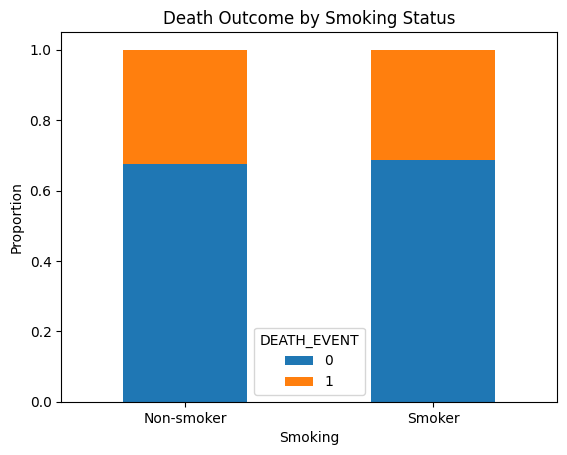

In [31]:
pd.crosstab(
    df["smoking"],
    df["DEATH_EVENT"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.xlabel("Smoking")
plt.ylabel("Proportion")
plt.title("Death Outcome by Smoking Status")
plt.xticks([0, 1], ["Non-smoker", "Smoker"], rotation=0)

plt.show()

3. Statistical Analysis


In [32]:
from scipy.stats import chi2_contingency

In [33]:
table = pd.crosstab(df["smoking"], df["DEATH_EVENT"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.007331473567119502
p-value: 0.9317652998235507


In [34]:
from scipy.stats import chi2_contingency

categorical_vars = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

for variable in categorical_vars:
    table = pd.crosstab(df[variable], df["DEATH_EVENT"])
    chi2, p, dof, expected = chi2_contingency(table)

    print(variable)
    print("p-value:", p)
    print()

anaemia
p-value: 0.3073160508415107

diabetes
p-value: 1.0

high_blood_pressure
p-value: 0.21410341199416905

sex
p-value: 1.0

smoking
p-value: 0.9317652998235507



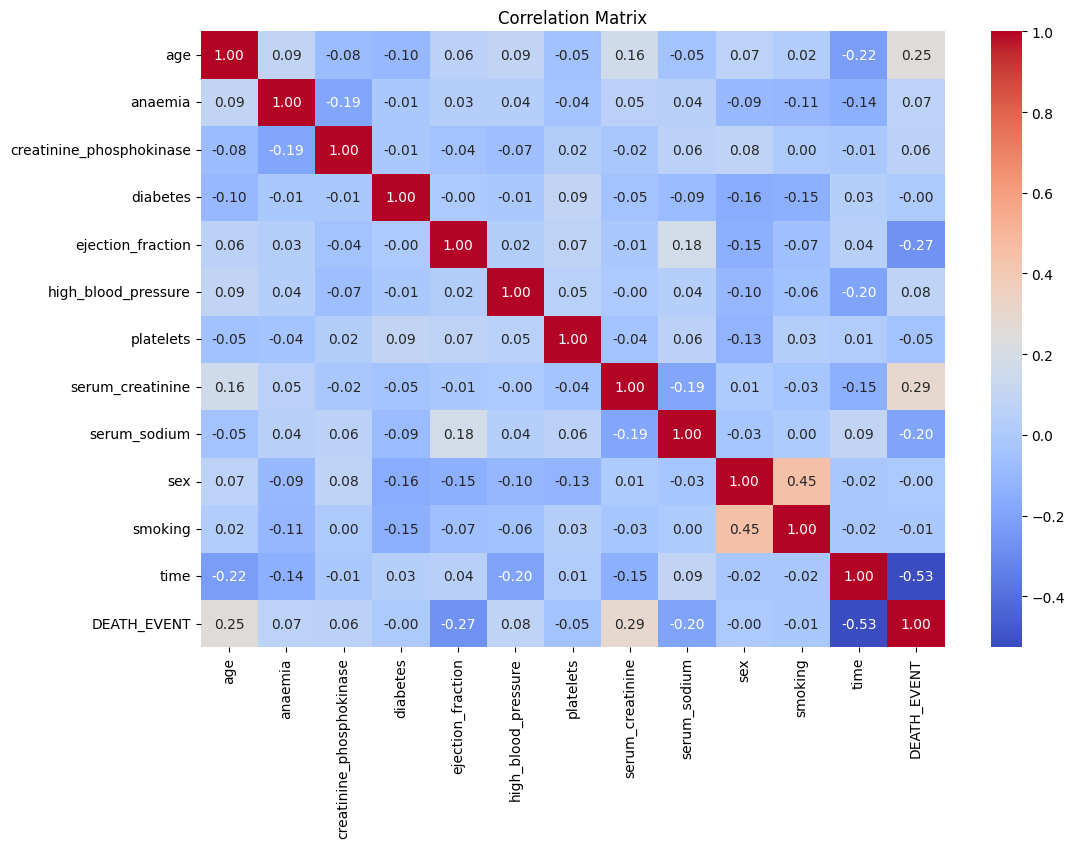

In [36]:
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [37]:
results = pd.DataFrame({
    "Variable": [
        "Age",
        "Ejection fraction",
        "Serum creatinine",
        "Serum sodium",
        "Time"
    ],
    "Correlation with DEATH_EVENT": [
        0.25,
        -0.27,
        0.29,
        -0.20,
        -0.53
    ]
})

results

,Variable,Correlation with DEATH_EVENT
0,Age,0.25
1,Ejection fraction,-0.27
2,Serum creatinine,0.29
3,Serum sodium,-0.20
4,Time,-0.53


In [40]:
results = pd.DataFrame({
    "Variable": [
        "Age",
        "Ejection fraction",
        "Serum creatinine"
    ],
    "Mean (No Death)": [
        58.76,
        40.27,
        1.18
    ],
    "Mean (Death)": [
        65.22,
        33.47,
        1.84
    ],
    "Correlation": [
        0.25,
        -0.27,
        0.29
    ],
    "p-value": [
        8.92e-06,
        2.45e-06,
        2.19e-07
    ]
})

results

,Variable,Mean (No Death),Mean (Death),Correlation,p-value
0,Age,58.76,65.22,0.25,8.920000e-06
1,Ejection fraction,40.27,33.47,-0.27,2.450000e-06
2,Serum creatinine,1.18,1.84,0.29,2.190000e-07


In [39]:
categorical_results = pd.DataFrame({
    "Variable": [
        "Anaemia",
        "Diabetes",
        "High blood pressure",
        "Sex",
        "Smoking"
    ],
    "Chi-square p-value": [
        0.3073,
        1.0000,
        0.2141,
        1.0000,
        0.9318
    ]
})

categorical_results

,Variable,Chi-square p-value
0,Anaemia,0.3073
1,Diabetes,1.0000
2,High blood pressure,0.2141
3,Sex,1.0000
4,Smoking,0.9318


In [46]:
X = df.drop(columns=["DEATH_EVENT", "time"])
y = df["DEATH_EVENT"]

In [47]:
print(X.shape)
print(y.shape)

(299, 11)
(299,)


4. Machine Learning

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)  #burda x_train, y_train eğitilecek %80 oranında özellik ve ölüm sonucunu; testler test edilecekleri
   #random state 42, stratify=y ile y nin dağılımını koruyacak şekilde bölünüyor

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(239, 11)
(60, 11)
(239,)
(60,)


In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
model = LogisticRegression(max_iter=1000)


In [58]:
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [59]:
y_pred = model.predict(X_test_scaled)

In [60]:
print(y_pred)

[0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0]


In [61]:
comparison = pd.DataFrame({
    "Actual values": y_test.values,
    "Predicted values": y_pred
})

comparison

,Actual values,Predicted values
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,1


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[35  6]
 [12  7]]


In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7


In [64]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.3684210526315789


In [65]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5384615384615384


In [66]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.4375


In [67]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [68]:
print(y_prob)


[0.45202122 0.27955608 0.15875727 0.46452392 0.05884686 0.07250925
 0.08375308 0.1041541  0.084195   0.54386518 0.57122887 0.31047554
 0.24090634 0.16909202 0.07313694 0.46711988 0.57184279 0.30268419
 0.56110494 0.11382296 0.0154583  0.2788708  0.16482279 0.0304672
 0.04442154 0.54708543 0.21118069 0.90067655 0.52844712 0.15591801
 0.07703648 0.19429709 0.1457477  0.76665461 0.05863395 0.27724012
 0.19886377 0.33202932 0.3469987  0.58418438 0.37951713 0.13682827
 0.14374528 0.02052038 0.04385465 0.05946254 0.10750286 0.0416481
 0.18833112 0.70688337 0.34419222 0.57971827 0.24058384 0.12890342
 0.07190563 0.72323632 0.11645125 0.60999225 0.05985872 0.09717895]


In [69]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7445442875481386


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.80        41
           1       0.54      0.37      0.44        19

    accuracy                           0.70        60
   macro avg       0.64      0.61      0.62        60
weighted avg       0.68      0.70      0.68        60



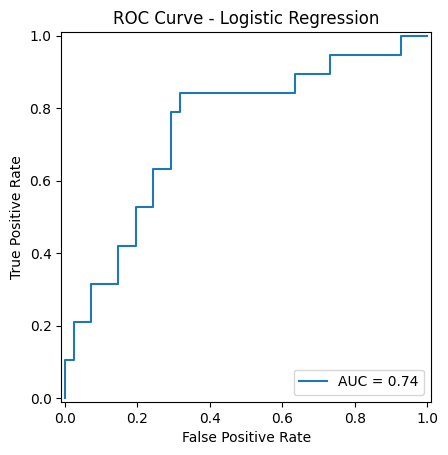

In [71]:
from sklearn.metrics import roc_curve, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc
).plot()

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.1 | Precision: 0.40 | Recall: 0.89 | F1: 0.55
Threshold: 0.2 | Precision: 0.54 | Recall: 0.79 | F1: 0.64
Threshold: 0.3 | Precision: 0.55 | Recall: 0.63 | F1: 0.59
Threshold: 0.4 | Precision: 0.50 | Recall: 0.42 | F1: 0.46
Threshold: 0.5 | Precision: 0.54 | Recall: 0.37 | F1: 0.44
Threshold: 0.6 | Precision: 0.80 | Recall: 0.21 | F1: 0.33
Threshold: 0.7 | Precision: 0.75 | Recall: 0.16 | F1: 0.26
Threshold: 0.8 | Precision: 1.00 | Recall: 0.05 | F1: 0.10
Threshold: 0.9 | Precision: 1.00 | Recall: 0.05 | F1: 0.10


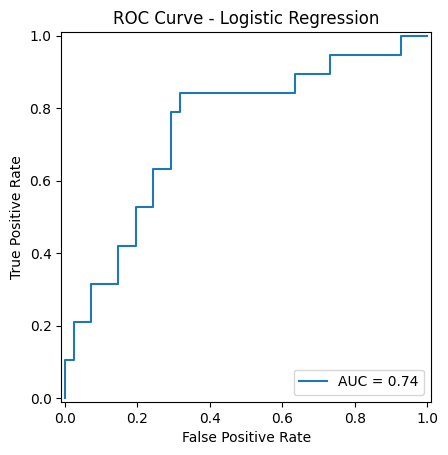

In [73]:
from sklearn.metrics import roc_curve, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc
).plot()

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [76]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [77]:
rf_pred = rf_model.predict(X_test)

print(rf_pred)

[0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0]


In [78]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(rf_prob[:10])

[0.39 0.11 0.22 0.53 0.2  0.33 0.05 0.49 0.15 0.86]


In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("ROC-AUC:", rf_auc)

Accuracy: 0.7
Precision: 0.5384615384615384
Recall: 0.3684210526315789
F1-score: 0.4375
ROC-AUC: 0.7971758664955071


In [80]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[35  6]
 [12  7]]


In [81]:
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_precision = precision_score(y_test, y_pred)
logreg_recall = recall_score(y_test, y_pred)
logreg_f1 = f1_score(y_test, y_pred)
logreg_auc = roc_auc_score(y_test, y_prob)

comparison_models = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [
        logreg_accuracy,
        logreg_precision,
        logreg_recall,
        logreg_f1,
        logreg_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

comparison_models

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.700000,0.700000
1,Precision,0.538462,0.538462
2,Recall,0.368421,0.368421
3,F1-score,0.437500,0.437500
4,ROC-AUC,0.744544,0.797176


In [82]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds_to_test:
    rf_pred_threshold = (rf_prob >= threshold).astype(int)

    rf_precision_t = precision_score(
        y_test, rf_pred_threshold, zero_division=0
    )
    rf_recall_t = recall_score(
        y_test, rf_pred_threshold
    )
    rf_f1_t = f1_score(
        y_test, rf_pred_threshold
    )

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {rf_precision_t:.2f} | "
        f"Recall: {rf_recall_t:.2f} | "
        f"F1: {rf_f1_t:.2f}"
    )

Threshold: 0.1 | Precision: 0.39 | Recall: 1.00 | F1: 0.56
Threshold: 0.2 | Precision: 0.48 | Recall: 0.84 | F1: 0.62
Threshold: 0.3 | Precision: 0.50 | Recall: 0.68 | F1: 0.58
Threshold: 0.4 | Precision: 0.56 | Recall: 0.53 | F1: 0.54
Threshold: 0.5 | Precision: 0.54 | Recall: 0.37 | F1: 0.44
Threshold: 0.6 | Precision: 0.67 | Recall: 0.32 | F1: 0.43
Threshold: 0.7 | Precision: 0.67 | Recall: 0.21 | F1: 0.32
Threshold: 0.8 | Precision: 0.50 | Recall: 0.05 | F1: 0.10
Threshold: 0.9 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


In [83]:
rf_model.feature_importances_

array([0.12131066, 0.02377497, 0.12717308, 0.02044821, 0.19031175,
       0.02550885, 0.10976529, 0.231363  , 0.10815197, 0.01990729,
       0.02228491])

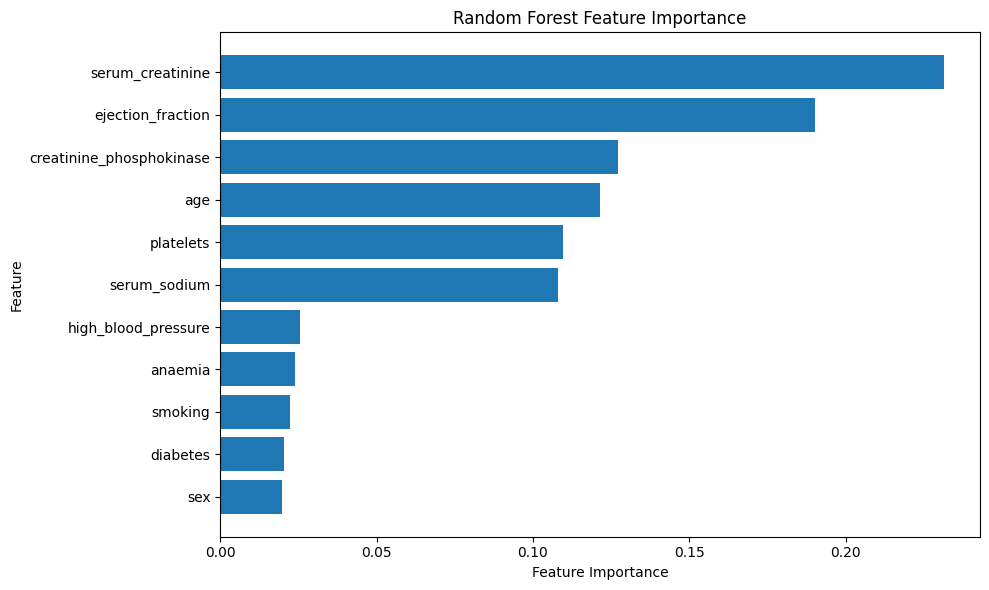

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()
